# CV HOMEWORK

## PART 1: using .txt files of correspondences

### 1.1 Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import LinearNDInterpolator
import cv2

### 1.2 Reading Images and txt files

In [2]:
img1 = cv2.imread("image01.jpg")
img2 = cv2.imread("image02.jpg")
img3 = cv2.imread("image03.jpg")
img4 = cv2.imread("image04.jpg")
img5 = cv2.imread("image05.jpg")

In [3]:
def txt_to_np_array(file):  
    File_data = np.loadtxt(file, dtype=str) 
    zzz = File_data[1:]
    ppp = []
    for i in range(0, len(zzz)):
        ppp.append([float(string) for string in zzz[i]]) 
    temp = np.array(ppp) 
    
    return temp

In [36]:
data12 = txt_to_np_array('rawmatches12.txt')
data23 = txt_to_np_array('rawmatches23.txt')
data34 = txt_to_np_array('rawmatches34.txt')
data45 = txt_to_np_array('rawmatches45.txt')

### 1.3 Homography Estimation

In [37]:
def get_H(P1,P2,T1,T2):
    N1 = np.zeros_like(P1)
    N1 = np.hstack((N1, np.ones((N1.shape[0], 1))))
    P1 = np.hstack((P1, np.ones((P1.shape[0], 1))))
    N2 = np.zeros_like(P2)
    N2 = np.hstack((N2, np.ones((N2.shape[0], 1))))
    P2 = np.hstack((P2, np.ones((P2.shape[0], 1))))
    for i in range(4):
      N1[i] = np.dot(T1,P1[i])
      N2[i] = np.dot(T2,P2[i])
    P1_new = N1[:,:-1]
    P2_new = N2[:,:-1]
    A = []
    for src, dst in zip(P1_new, P2_new):
        x, y = src
        x_, y_ = dst
        A.append([-x, -y, -1, 0, 0, 0, x * x_, y * x_, x_])
        A.append([0, 0, 0, -x, -y, -1, x * y_, y * y_, y_])
    A = np.array(A)
    _, _, V = np.linalg.svd(A)
    H_ = V[-1, :].reshape(3, 3)
    T2_inv = np.linalg.inv(T2)
    H = np.dot(np.dot(T2_inv,H_),T1)
    
    return H

In [38]:
def normalize(P1, P2):
    P1_mean = np.mean(P1, axis=0)
    P2_mean = np.mean(P2, axis=0)
    P1_new = P1 - P1_mean
    P2_new = P2 - P2_mean
    # T1 = np.array([[1, 0, -P1_mean[0]],[0, 1, -P1_mean[1]],[0, 0, 1]])
    # T2 = np.array([[1, 0, -P2_mean[0]],[0, 1, -P2_mean[1]],[0, 0, 1]])
    D1 = np.sqrt(np.sum((P1_new)**2, axis=1))
    D2 = np.sqrt(np.sum((P2_new)**2, axis=1))
    S1 = np.sqrt(2) / np.mean(D1)
    s2 = np.sqrt(2) / np.mean(D2)
    T1_new = np.array([[S1, 0, 0],[0, S1, 0],[0, 0, 1]])
    T2_new = np.array([[s2, 0, 0],[0, s2, 0],[0, 0, 1]])
    return T1_new, T2_new

### 1.4 RANSAC

In [45]:
def RANSAC(arr1,arr2,iterations,threshold):
    final_H = np.array((3,3))
    best_inliers = []
    T1, T2 = normalize(arr1, arr2)
    for i in range(iterations):
        indices = np.random.choice(len(arr1), 4, replace=False)
        P1 = arr1[indices]
        P2 = arr2[indices]
        H = get_H(P1,P2,T1,T2)
        Pnew = np.dot(H, np.vstack((arr1.T, np.ones((1, len(arr1))))))
        Pnew = Pnew[:2] / Pnew[2]
        Pnew = Pnew.T
        err = np.sqrt(np.sum((Pnew - arr2)**2, axis=1))
        inliers = np.where(err < threshold)[0]
        if len(inliers) > len(best_inliers):
            final_H = H
            best_inliers = inliers
    return final_H

In [46]:
iterations = 10000
threshold = 10
H12 = RANSAC(data12[:,2:], data12[:,:2],iterations,threshold)
H23 = RANSAC(data23[:,2:], data23[:,:2],iterations,threshold)
H34 = RANSAC(data34[:,2:], data34[:,:2],iterations,threshold)
H45 = RANSAC(data45[:,2:], data45[:,:2],iterations,threshold)


In [9]:
H13 = np.matmul(H12,H23)
H14 = np.matmul(H13,H34)
H15 = np.matmul(H14,H45)
H31 = np.linalg.inv(H13)
H32 = np.linalg.inv(H23)
H35 = np.matmul(H34, H45)

### 1.5 Warping

In [11]:
def WARP(img, H):
    p,q,r = img.shape
    corner_x = []
    corner_y = []
    for i in [0,p-1]:
        for j in [0, q-1]:
            transformed_point = np.dot(H, np.array([j,i, 1]))
            corner_x.append(int(transformed_point[0] / transformed_point[2]))
            corner_y.append(int(transformed_point[1] / transformed_point[2]))        
    lower_limit_x = min(corner_x)
    upper_limit_x = max(corner_x)
    lower_limit_y = min(corner_y)
    upper_limit_y = max(corner_y)
    a,b = upper_limit_y-lower_limit_y, upper_limit_x-lower_limit_x
    warped_img = np.zeros((a+1,b+1,3))
    xx = []
    yy = []
    ppp = []
    for y in range(p):
        for x in range(q):
            transformed_point = np.dot(H, np.array([x, y, 1]))
            x_input = int(transformed_point[0] / transformed_point[2])
            y_input = int(transformed_point[1] / transformed_point[2])
            warped_img[y_input-lower_limit_y,x_input-lower_limit_x] = img[y,x]
            xx.append(x_input-lower_limit_x)
            yy.append(y_input-lower_limit_y)
            ppp.append(img[y,x])
    # interp = LinearNDInterpolator(np.vstack((xx,yy)).T, ppp)
    for i in range(0,b):
        for j in range(0,a):
            if(warped_img[j,i,0] < 1 and warped_img[j,i,1] < 1 and warped_img[j,i,2] < 1):
                warped_img[j,i] = np.median(warped_img[j-1:j+2,i-1:i+2])

    return warped_img.astype(int), lower_limit_x, lower_limit_y, upper_limit_x, upper_limit_y

In [12]:
new_img1,x1,y1,u1,v1 = WARP(img1, H31)
new_img2,x2,y2,u2,v2 = WARP(img2, H32)
new_img3,x3,y3,u3,v3 = img3,0,0,img3.shape[1],img3.shape[0]
new_img4,x4,y4,u4,v4 = WARP(img4, H34)
new_img5,x5,y5,u5,v5 = WARP(img5, H35)

c:\Users\nilad\Downloads\PY\Lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\nilad\Downloads\PY\Lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\nilad\AppData\Local\Temp\ipykernel_10856\2121412815.py:34: RuntimeWarning: invalid value encountered in cast
  return warped_img.astype(int), lower_limit_x, lower_limit_y, upper_limit_x, upper_limit_y


In [13]:
cv2.imwrite('warped_img1.jpg',new_img1)
cv2.imwrite('warped_img2.jpg',new_img2)
cv2.imwrite('warped_img3.jpg',new_img3)
cv2.imwrite('warped_img4.jpg',new_img4)
cv2.imwrite('warped_img5.jpg',new_img5)

True

### 1.6 Prep for Stitching

In [14]:
final_left_limit = min([x1,x2,x3,x4,x5])
final_low_y = min([y1,y2,y3,y4,y5])
final_right_limit = max([u1,u2,u3,u4,u5])
final_high_y = max([v1,v2,v3,v4,v5])
 
final_size_x, final_size_y = 7500,5500
displacement_x, displacement_y = 2000,1000

In [15]:
def get_canvas_img(img, x_offset, y_offset):
    output = np.zeros((final_size_y,final_size_x,3))
    aa,bb,z = img.shape
    for i in range(0,aa):
        for j in range(0,bb):
            output[i+displacement_y+y_offset,j+displacement_x+x_offset] = img[i,j]
    return output.astype(int)

In [16]:
canvas_img1 = get_canvas_img(new_img1,x1,y1)
canvas_img2 = get_canvas_img(new_img2,x2,y2)
canvas_img3 = get_canvas_img(new_img3,x3,y3)
canvas_img4 = get_canvas_img(new_img4,x4,y4)
canvas_img5 = get_canvas_img(new_img5,x5,y5)

### 1.7 Stitching and Blending

In [17]:
def BLEND(imgx, imgy, left, right):
    a,b,c = imgx.shape
    den = right-left
    output = np.zeros((a,b,c))
    for i in range(0,a):
        if(i<left):
            alpha = 1
        if(i>right):
            alpha = 0
        if(i>=left and i<=right):
            alpha = (right-i)/den
        for j in range(0,b):
            if(imgx[i,j,0] < 1 and imgx[i,j,1] < 1 and imgx[i,j,2] < 1):
                output[i,j] = imgy[i,j]
            elif(imgy[i,j,0] < 1 and imgy[i,j,1] < 1 and imgy[i,j,2] < 1):
                output[i,j] = imgx[i,j]
            else:
                output[i,j] = alpha*imgx[i,j] + (1-alpha)* imgy[i,j]
    return output.astype(int)

In [18]:
final_img_combined = BLEND(BLEND(BLEND(BLEND(canvas_img1, canvas_img2,displacement_x+x2, displacement_x+u1),canvas_img3,displacement_x+x3,displacement_x+u2),canvas_img4,displacement_x+x4,displacement_x+u3),canvas_img5,displacement_x+x5,displacement_x+u4)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


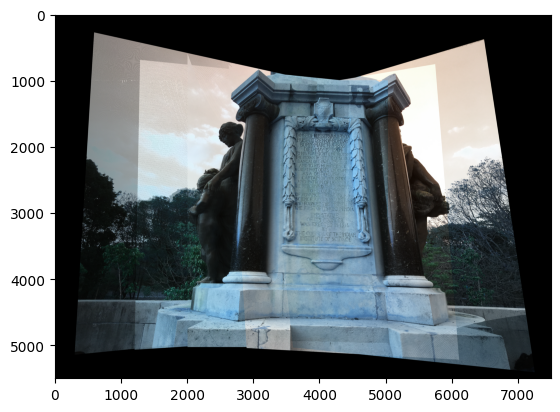

In [19]:
plt.imshow(final_img_combined)

## PART 2: Using SIFT feature matches

In [20]:
image1 = cv2.imread('1.jpg')
image2 = cv2.imread('2.jpg')
image3 = cv2.imread('3.jpg')
image4 = cv2.imread('4.jpg')
image5 = cv2.imread('5.jpg')

image1 = cv2.pyrDown(image1)
image1 = cv2.pyrDown(image1)
# image1 = cv2.pyrDown(image1)
# image1 = cv2.pyrDown(image1)

image2 = cv2.pyrDown(image2)
image2 = cv2.pyrDown(image2)
# image2 = cv2.pyrDown(image2)
# image2 = cv2.pyrDown(image2)

image3 = cv2.pyrDown(image3)
image3 = cv2.pyrDown(image3)
# image3 = cv2.pyrDown(image3)
# image3 = cv2.pyrDown(image3)

image4 = cv2.pyrDown(image4)
image4 = cv2.pyrDown(image4)
# image4 = cv2.pyrDown(image4)
# image4 = cv2.pyrDown(image4)

image5 = cv2.pyrDown(image5)
image5 = cv2.pyrDown(image5)
# image5 = cv2.pyrDown(image5)
# image5 = cv2.pyrDown(image5)

sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(image1, None)
keypoints2, descriptors2 = sift.detectAndCompute(image2, None)
keypoints3, descriptors3 = sift.detectAndCompute(image3, None)
keypoints4, descriptors4 = sift.detectAndCompute(image4, None)
keypoints5, descriptors5 = sift.detectAndCompute(image5, None)
bf = cv2.BFMatcher()
matches12 = bf.knnMatch(descriptors1, descriptors2, k=2)
matches23 = bf.knnMatch(descriptors2, descriptors3, k=2)
matches34 = bf.knnMatch(descriptors3, descriptors4, k=2)
matches45 = bf.knnMatch(descriptors4, descriptors5, k=2)
good_matches12 = []
for m, n in matches12:
    if m.distance < 0.75 * n.distance:
        good_matches12.append(m)
points1 = np.float32([keypoints1[m.queryIdx].pt for m in good_matches12]).reshape(-1, 1, 2)
points2 = np.float32([keypoints2[m.trainIdx].pt for m in good_matches12]).reshape(-1, 1, 2)
matched_points12 = np.concatenate((points1, points2), axis=1)
good_matches23 = []
for m, n in matches23:
    if m.distance < 0.75 * n.distance:
        good_matches23.append(m)
points2 = np.float32([keypoints2[m.queryIdx].pt for m in good_matches23]).reshape(-1, 1, 2)
points3 = np.float32([keypoints3[m.trainIdx].pt for m in good_matches23]).reshape(-1, 1, 2)
matched_points23 = np.concatenate((points2, points3), axis=1)
good_matches34 = []
for m, n in matches34:
    if m.distance < 0.75 * n.distance:
        good_matches34.append(m)
points3 = np.float32([keypoints3[m.queryIdx].pt for m in good_matches34]).reshape(-1, 1, 2)
points4 = np.float32([keypoints4[m.trainIdx].pt for m in good_matches34]).reshape(-1, 1, 2)
matched_points34 = np.concatenate((points3, points4), axis=1)
good_matches45 = []
for m, n in matches45:
    if m.distance < 0.75 * n.distance:
        good_matches45.append(m)
points4 = np.float32([keypoints4[m.queryIdx].pt for m in good_matches45]).reshape(-1, 1, 2)
points5 = np.float32([keypoints5[m.trainIdx].pt for m in good_matches45]).reshape(-1, 1, 2)
matched_points45 = np.concatenate((points4, points5), axis=1)


In [21]:
data12 = matched_points12.reshape(matched_points12.shape[0], 4)
data23 = matched_points23.reshape(matched_points23.shape[0], 4)
data34 = matched_points34.reshape(matched_points34.shape[0], 4)
data45 = matched_points45.reshape(matched_points45.shape[0], 4)

In [22]:
iterations = 10000
threshold = 10
H12 = RANSAC(data12[:,2:], data12[:,:2],iterations,threshold)
H23 = RANSAC(data23[:,2:], data23[:,:2],iterations,threshold)
H34 = RANSAC(data34[:,2:], data34[:,:2],iterations,threshold)
H45 = RANSAC(data45[:,2:], data45[:,:2],iterations,threshold)

In [23]:
H13 = np.matmul(H12,H23)
H14 = np.matmul(H13,H34)
H15 = np.matmul(H14,H45)
H31 = np.linalg.inv(H13)
H32 = np.linalg.inv(H23)
H35 = np.matmul(H34, H45)

In [24]:
new_img1,x1,y1,u1,v1 = WARP(image1, H31)
new_img2,x2,y2,u2,v2 = WARP(image2, H32)
new_img3,x3,y3,u3,v3 = image3,0,0,image3.shape[1],image3.shape[0]
new_img4,x4,y4,u4,v4 = WARP(image4, H34)
new_img5,x5,y5,u5,v5 = WARP(image5, H35)

C:\Users\nilad\AppData\Local\Temp\ipykernel_10856\2121412815.py:34: RuntimeWarning: invalid value encountered in cast
  return warped_img.astype(int), lower_limit_x, lower_limit_y, upper_limit_x, upper_limit_y


In [25]:

final_left_limit = min([x1,x2,x3,x4,x5])
final_low_y = min([y1,y2,y3,y4,y5])
final_right_limit = max([u1,u2,u3,u4,u5])
final_high_y = max([v1,v2,v3,v4,v5])
 
final_size_x, final_size_y = 4000,2400
displacement_x, displacement_y = 800,400

In [26]:
def get_canvas_img(img, x_offset, y_offset):
    output = np.zeros((final_size_y,final_size_x,3))
    aa,bb,z = img.shape
    for i in range(0,aa):
        for j in range(0,bb):
            output[i+displacement_y+y_offset,j+displacement_x+x_offset] = img[i,j]
    return output.astype(int)

In [27]:

canvas_img1 = get_canvas_img(new_img1,x1,y1)
canvas_img2 = get_canvas_img(new_img2,x2,y2)
canvas_img3 = get_canvas_img(new_img3,x3,y3)
canvas_img4 = get_canvas_img(new_img4,x4,y4)
canvas_img5 = get_canvas_img(new_img5,x5,y5)

In [28]:

blend12345 = BLEND(BLEND(BLEND(BLEND(canvas_img1, canvas_img2,displacement_x+x2, displacement_x+u1),canvas_img3,displacement_x+x3,displacement_x+u2),canvas_img4,displacement_x+x4,displacement_x+u3),canvas_img5,displacement_x+x5,displacement_x+u4)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


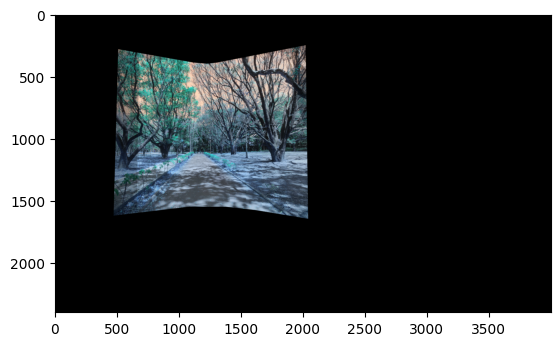

In [29]:
plt.imshow(blend12345)

In [30]:
cv2.imwrite("sift.jpg", blend12345)

True